In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
# Read the CSV file with correct column names
wine_df = pd.read_csv('wine_data.csv')

# Rename columns using dictionary
wine_df = wine_df.rename(columns={
    'class_label': 'Wine_Type',
    'alcohol': 'Alcohol',
    'malic_acid': 'Malic_Acid',
    'ash': 'Ash',
    'alcalinity_of_ash': 'Alcalinity_of_Ash',
    'magnesium': 'Magnesium',
    'total_phenols': 'Total_Phenols',
    'flavanoids': 'Flavanoids',
    'nonflavanoid_phenols': 'Nonflavanoid_Phenols',
    'proanthocyanins': 'Proanthocyanins',
    'color_intensity': 'Color_Intensity',
    'hue': 'Hue',
    'OD280/OD315_of_diluted_wines': 'OD_Ratio',
    'proline': 'Proline'
})

# Verify the new column names
print(wine_df.columns.tolist())

['Wine_Type', 'Alcohol', 'Malic_Acid', 'Ash', 'Alcalinity_of_Ash', 'Magnesium', 'Total_Phenols', 'Flavanoids', 'Nonflavanoid_Phenols', 'Proanthocyanins', 'Color_Intensity', 'Hue', 'OD_Ratio', 'Proline']


In [19]:
wine_df

,Wine_Type,Alcohol,Malic_Acid,Ash,Alcalinity_of_Ash,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD_Ratio,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [27]:
# Method 1: Using column names in a list
new_df = wine_df[['Wine_Type', 'Alcohol', 'Malic_Acid']]

# OR Method 2: Using loc accessor
# new_df = wine_df.loc[:, ['Wine_Type', 'Alcohol', 'Proline']]

# Verify the new DataFrame
print(new_df.head())

   Wine_Type  Alcohol  Malic_Acid
0          1    14.23        1.71
1          1    13.20        1.78
2          1    13.16        2.36
3          1    14.37        1.95
4          1    13.24        2.59


<Axes: xlabel='Alcohol', ylabel='Density'>

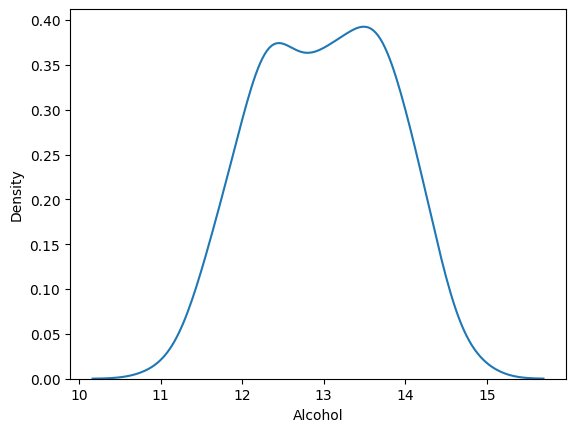

In [25]:
sns.kdeplot(new_df['Alcohol'])

<Axes: xlabel='Malic_Acid', ylabel='Density'>

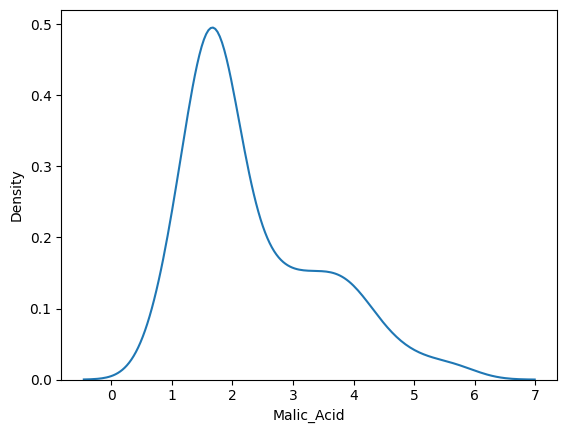

In [28]:
sns.kdeplot(new_df['Malic_Acid'])

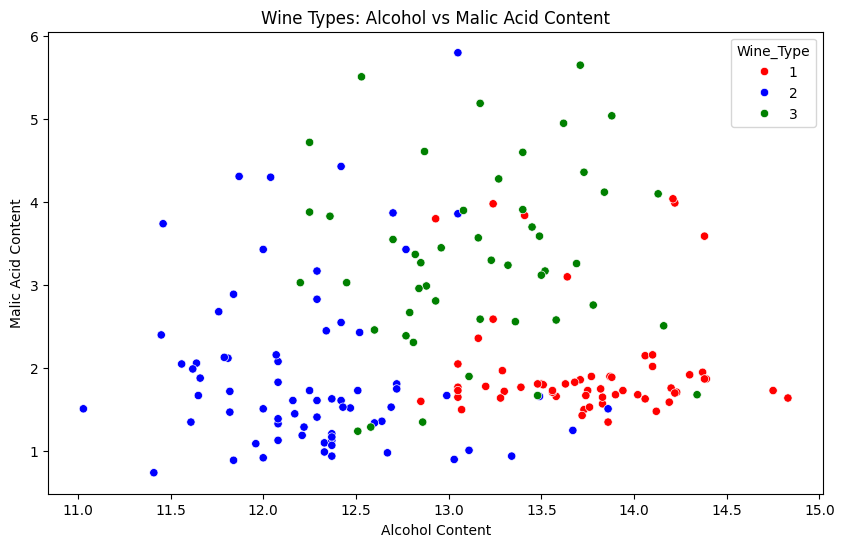

In [32]:
plt.figure(figsize=(10,6))
color_dict = {1:"red", 2:"blue", 3:"green"}
sns.scatterplot(data=new_df, x='Alcohol', y='Malic_Acid', hue='Wine_Type', palette=color_dict)
plt.title('Wine Types: Alcohol vs Malic Acid Content')
plt.xlabel('Alcohol Content')
plt.ylabel('Malic Acid Content')
plt.show()

In [34]:

df=new_df
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(df.drop('Wine_Type',axis=1),df['Wine_Type'],test_size=0.3,random_state=0)

In [35]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()

In [36]:
scaler.fit(X_train)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [37]:
X_train_scaled=scaler.transform(X_train)

In [38]:
X_test_scaled=scaler.transform(X_test)

In [39]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)

In [40]:
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [42]:
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic_Acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


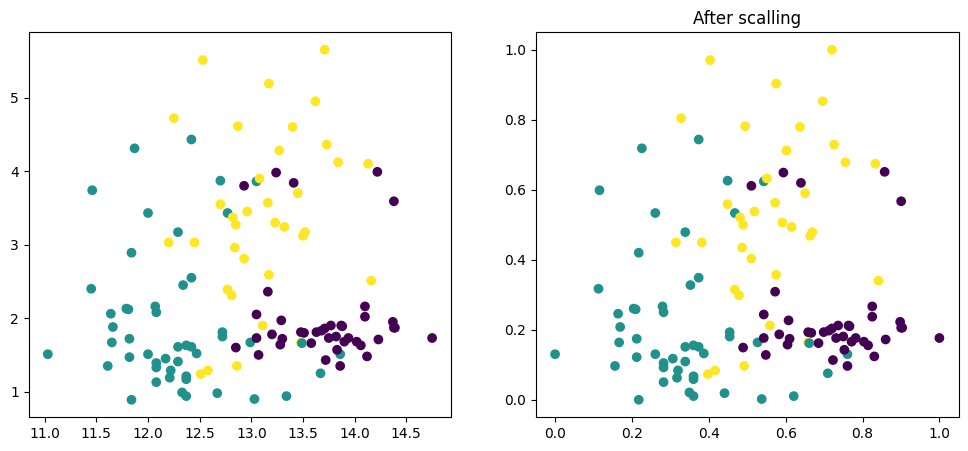

In [45]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(X_train['Alcohol'],X_train['Malic_Acid'],c=Y_train)
ax2.scatter(X_train_scaled['Alcohol'],X_train_scaled['Malic_Acid'],c=Y_train)
ax2.set_title("After scalling")
plt.show()